# Mean Sparsity Calculation of Connectivity Matrices

This notebook computes and visualizes the mean sparsity of connectivity matrices for each PySPI and Skarf metric in the aggregated Parquet file. 

Sparsity is calculated as the proportion of matrix elements below a given threshold. We sweep through multiple threshold values [0.0, 0.05, 0.1, 0.3] to understand the sparsity characteristics across different tolerance levels.

Sparsity is averaged across all subjects, sessions, runs, and lags (for Skarf metrics).

In [1]:
from pathlib import Path
from joblib import Parallel, delayed

import numpy as np
import pandas as pd
import pyarrow.parquet as pq 
from matplotlib import pyplot as plt

## Load parquet data and inspect structure

In [2]:
parquet_path = Path("/srv/projects/skarf/data_aggregation/hcp_1200_rfmri_schaefer.parquet")
pq_file = pq.ParquetFile(parquet_path)
pq_file.metadata

  created_by: Polars
  num_columns: 17
  num_rows: 596532
  num_row_groups: 60
  format_version: 1.0
  serialized_size: 86343

In [3]:
pq_file.schema

required group field_id=-1 root {
  optional binary field_id=-1 method (String);
  optional int32 field_id=-1 func_id;
  optional int32 field_id=-1 sub_id;
  optional binary field_id=-1 func (String);
  optional binary field_id=-1 sub (String);
  optional int32 field_id=-1 ses (Int(bitWidth=8, isSigned=false));
  optional int32 field_id=-1 run (Int(bitWidth=8, isSigned=false));
  optional boolean field_id=-1 success;
  optional float field_id=-1 run_time;
  optional float field_id=-1 peak_mem_mb;
  optional binary field_id=-1 err (String);
  optional group field_id=-1 mat (List) {
    repeated group field_id=-1 list {
      optional float field_id=-1 element;
    }
  }
  optional float field_id=-1 train_score;
  optional float field_id=-1 val_score;
  optional float field_id=-1 test_score;
  optional group field_id=-1 scores (List) {
    repeated group field_id=-1 list {
      optional float field_id=-1 element;
    }
  }
  optional int64 field_id=-1 lag;
}

In [4]:
pq_file.read_row_group(0).to_pandas().head()

,method,func_id,sub_id,func,sub,ses,run,success,run_time,peak_mem_mb,err,mat,train_score,val_score,test_score,scores,lag
0,pyspi,0,0,cov_EmpiricalCovariance,181131,1,1,True,0.930558,1.232801,None,"[nan, 0.58204854, 0.52128285, 0.5169972, -0.26...",NaN,NaN,NaN,None,NaN
1,pyspi,0,0,cov_EmpiricalCovariance,181131,1,2,True,0.014127,1.231199,None,"[nan, 0.46771437, 0.2173629, 0.22710979, -0.01...",NaN,NaN,NaN,None,NaN
2,pyspi,0,0,cov_EmpiricalCovariance,181131,2,1,True,0.014291,1.231146,None,"[nan, 0.40729353, 0.1916287, 0.46409807, -0.12...",NaN,NaN,NaN,None,NaN
3,pyspi,0,0,cov_EmpiricalCovariance,181131,2,2,True,0.035801,1.231123,None,"[nan, 0.36609778, 0.18175854, 0.26420525, 0.15...",NaN,NaN,NaN,None,NaN
4,pyspi,0,1,cov_EmpiricalCovariance,245333,1,1,True,0.897536,1.232801,None,"[nan, 0.44370365, 0.36066413, 0.46114182, -0.3...",NaN,NaN,NaN,None,NaN


## Check for failed runs

In [5]:
failed_rows_per_group = []
printed = False

for num in range(pq_file.num_row_groups):
    table = pq_file.read_row_group(num, columns=['success'])
    num_failed = sum(1 for row in table.to_pylist() if not row['success'])
    failed_rows_per_group.append(num_failed)
    
    if num_failed > 0 and not printed:
        mask = ~table['success'].to_numpy()
        
        if mask.any():
            failed_row_idx = mask.argmax()
            full_row = pq_file.read_row_group(num).slice(failed_row_idx, 1).to_pandas()
            display(full_row)
            printed = True
        
        else:
            print("No rows with success == False in this table.")

print("Total number of failed runs:", sum(failed_rows_per_group))

,method,func_id,sub_id,func,sub,ses,run,success,run_time,peak_mem_mb,err,mat,train_score,val_score,test_score,scores,lag
0,pyspi,3,3,cov_GraphicalLassoCV,187547,1,2,False,82.887299,28.208263,FloatingPointError('Non SPD result: the system...,None,NaN,NaN,NaN,None,NaN


Total number of failed runs: 870


## Visualize a connectivity matrix

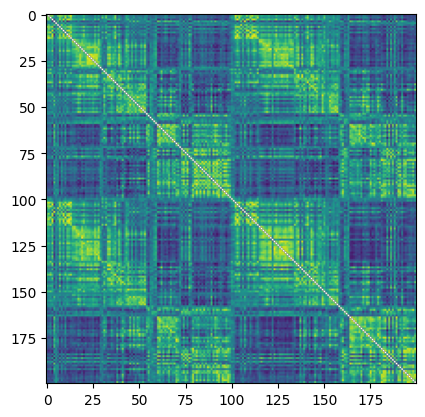

In [6]:
mat_sample = pq_file.read_row_group(0, columns=['mat'])['mat'][0]
mat_np = np.array(mat_sample.as_py())
plt.imshow(mat_np.reshape(200, 200), cmap='viridis')
plt.show()

## Define sparsity computation functions

In [7]:
THRESHOLDS = [0.0, 0.05, 0.1, 0.3]

def compute_sparsity_multi_threshold(mat_array, thresholds=THRESHOLDS):
    """
    Compute sparsity of a flattened connectivity matrix at multiple thresholds.
    Sparsity at threshold t = (number of elements with |value| < t) / (total elements)
    For t == 0.0, use a small tolerance to avoid floating point issues.
    """
    mat_np = np.array(mat_array.as_py())
    total_elements = len(mat_np)
    
    if total_elements == 0:
        return {float(t): np.nan for t in thresholds}
    
    abs_mat = np.abs(mat_np)
    sparsity_dict = {}
    tol = 1e-10

    for threshold in thresholds:
        if threshold == 0.0:
            n_below_threshold = np.sum(abs_mat < tol)
        else:
            n_below_threshold = np.sum(abs_mat < threshold)
        sparsity_dict[float(threshold)] = n_below_threshold / total_elements
    
    return sparsity_dict

In [8]:
def compute_sparsity_batch(batch_table):
    """Compute sparsity for a batch of connectivity matrices at multiple thresholds."""
    results = []
    
    for i in range(len(batch_table)):
        row = batch_table.slice(i, 1)
        
        success = row['success'][0].as_py()
        if not success:
            continue
        
        sparsity_dict = compute_sparsity_multi_threshold(row['mat'][0])
        
        base_metadata = {
            'method': row['method'][0].as_py(),
            'func_id': row['func_id'][0].as_py(),
            'func': row['func'][0].as_py(),
            'sub': row['sub'][0].as_py(),
            'ses': row['ses'][0].as_py(),
            'run': row['run'][0].as_py(),
            'lag': row['lag'][0].as_py(),
        }
        
        result = {**base_metadata, **{f'sparsity_t{t:.2f}': s for t, s in sparsity_dict.items()}}
        results.append(result)
    
    return results

In [9]:
def process_row_group(row_group_idx, parquet_path):
    """
    Process a single row group and return sparsity results.
    """
    pq_file = pq.ParquetFile(parquet_path)
    
    batch = pq_file.read_row_group(
        row_group_idx, 
        columns=['method', 'func_id', 'func', 'sub', 'ses', 'run', 'lag', 'success', 'mat']
    )
    
    success_array = batch['success'].to_pylist()
    n_success = sum(success_array)
    n_failed = sum(not s for s in success_array)
    
    batch_results = compute_sparsity_batch(batch)
    
    return batch_results, n_success, n_failed

## Batch processing and parallel computation

In [10]:
n_jobs = 23

print(f"Processing {pq_file.num_row_groups} row groups using {n_jobs} parallel jobs...")
print(f"Computing sparsity for {len(THRESHOLDS)} threshold values: {THRESHOLDS[0]:.2f} to {THRESHOLDS[-1]:.2f}")

results = Parallel(n_jobs=n_jobs, verbose=10)(
    delayed(process_row_group)(i, parquet_path) 
    for i in range(pq_file.num_row_groups)
)

all_results = []
n_success = 0
n_failed = 0

for batch_results, batch_success, batch_failed in results:
    all_results.extend(batch_results)
    n_success += batch_success
    n_failed += batch_failed

df_sparsity = pd.DataFrame(all_results)
print(f"\nProcessing complete:")
print(f"  Successful runs: {n_success:,}")
print(f"  Failed runs: {n_failed:,}")
print(f"  Total observations processed for sparsity: {len(df_sparsity):,}")
print(f"  Total sparsity columns: {len([c for c in df_sparsity.columns if c.startswith('sparsity_')])}")
df_sparsity.head()

Processing 60 row groups using 23 parallel jobs...
Computing sparsity for 4 threshold values: 0.00 to 0.30


[Parallel(n_jobs=23)]: Using backend LokyBackend with 23 concurrent workers.


[Parallel(n_jobs=23)]: Done   4 tasks      | elapsed:  1.2min
[Parallel(n_jobs=23)]: Done  15 tasks      | elapsed:  1.4min
[Parallel(n_jobs=23)]: Done  15 tasks      | elapsed:  1.4min
[Parallel(n_jobs=23)]: Done  22 out of  60 | elapsed:  1.5min remaining:  2.5min
[Parallel(n_jobs=23)]: Done  22 out of  60 | elapsed:  1.5min remaining:  2.5min
[Parallel(n_jobs=23)]: Done  29 out of  60 | elapsed:  2.5min remaining:  2.7min
[Parallel(n_jobs=23)]: Done  29 out of  60 | elapsed:  2.5min remaining:  2.7min
[Parallel(n_jobs=23)]: Done  36 out of  60 | elapsed:  2.8min remaining:  1.9min
[Parallel(n_jobs=23)]: Done  36 out of  60 | elapsed:  2.8min remaining:  1.9min
[Parallel(n_jobs=23)]: Done  43 out of  60 | elapsed:  2.9min remaining:  1.1min
[Parallel(n_jobs=23)]: Done  43 out of  60 | elapsed:  2.9min remaining:  1.1min
[Parallel(n_jobs=23)]: Done  50 out of  60 | elapsed:  3.6min remaining:   42.7s
[Parallel(n_jobs=23)]: Done  50 out of  60 | elapsed:  3.6min remaining:   42.7s
[Par


Processing complete:
  Successful runs: 595,662
  Failed runs: 870
  Total observations processed for sparsity: 595,662
  Total sparsity columns: 4


,method,func_id,func,sub,ses,run,lag,sparsity_t0.00,sparsity_t0.05,sparsity_t0.10,sparsity_t0.30
0,pyspi,0,cov_EmpiricalCovariance,181131,1,1,NaN,0.0,0.10925,0.21405,0.59680
1,pyspi,0,cov_EmpiricalCovariance,181131,1,2,NaN,0.0,0.12745,0.25250,0.65555
2,pyspi,0,cov_EmpiricalCovariance,181131,2,1,NaN,0.0,0.14645,0.28375,0.72545
3,pyspi,0,cov_EmpiricalCovariance,181131,2,2,NaN,0.0,0.12250,0.23950,0.64680
4,pyspi,0,cov_EmpiricalCovariance,245333,1,1,NaN,0.0,0.13780,0.27650,0.70945


## Aggregate and summarize sparsity results

In [11]:
sparsity_cols = [col for col in df_sparsity.columns if col.startswith('sparsity_')]

agg_dict = {col: ['mean', 'std', 'count'] for col in sparsity_cols}

mean_sparsity = df_sparsity.groupby(['method', 'func_id', 'func']).agg(agg_dict).round(4)

mean_sparsity.columns = ['_'.join(col).strip() for col in mean_sparsity.columns.values]
mean_sparsity = mean_sparsity.reset_index()

# Sort by method and by mean sparsity at threshold 0.1
mean_sparsity = mean_sparsity.sort_values(['method', 'sparsity_t0.10_mean'], ascending=[True, False])

print(f"\nMean Sparsity Summary:")
print("=" * 80)

mean_sparsity.head(20)


Mean Sparsity Summary:


,method,func_id,func,sparsity_t0.00_mean,sparsity_t0.00_std,sparsity_t0.00_count,sparsity_t0.05_mean,sparsity_t0.05_std,sparsity_t0.05_count,sparsity_t0.10_mean,sparsity_t0.10_std,sparsity_t0.10_count,sparsity_t0.30_mean,sparsity_t0.30_std,sparsity_t0.30_count
17,pyspi,38,xcorr_mean_sig-True,0.0000,0.0000,3468,0.9950,0.0000,3468,0.9950,0.0000,3468,0.9950,0.0000,3468
18,pyspi,40,xcorr_mean_sig-False,0.0000,0.0000,3468,0.9950,0.0000,3468,0.9950,0.0000,3468,0.9950,0.0000,3468
31,pyspi,67,bary_euclidean_mean,0.9950,0.0000,3468,0.9950,0.0000,3468,0.9950,0.0000,3468,0.9950,0.0000,3468
34,pyspi,86,reci,0.0000,0.0000,3468,0.9948,0.0007,3468,0.9950,0.0000,3468,0.9950,0.0000,3468
48,pyspi,135,te_symbolic_k-10_kt-1_l-1_lt-1,0.0000,0.0000,3468,0.9950,0.0000,3468,0.9950,0.0000,3468,0.9950,0.0000,3468
111,pyspi,241,sgc_parametric_mean_fs-1_fmin-0-25_fmax-0-5_or...,0.0003,0.0001,3468,0.9950,0.0000,3468,0.9950,0.0000,3468,0.9950,0.0000,3468
117,pyspi,250,sgc_parametric_max_fs-1_fmin-0-25_fmax-0-5_ord...,0.0002,0.0001,3468,0.9950,0.0001,3468,0.9950,0.0000,3468,0.9950,0.0000,3468
46,pyspi,133,gc_gaussian_k-1_kt-1_l-1_lt-1,0.0001,0.0001,3468,0.9920,0.0037,3468,0.9949,0.0004,3468,0.9950,0.0000,3468
47,pyspi,134,te_symbolic_k-1_kt-1_l-1_lt-1,0.0001,0.0001,3468,0.9920,0.0037,3468,0.9949,0.0004,3468,0.9950,0.0000,3468
109,pyspi,239,sgc_parametric_mean_fs-1_fmin-1e-05_fmax-0-5_o...,0.0001,0.0000,3468,0.9753,0.0128,3468,0.9941,0.0015,3468,0.9950,0.0000,3468


## Visualize sparsity across methods and functions

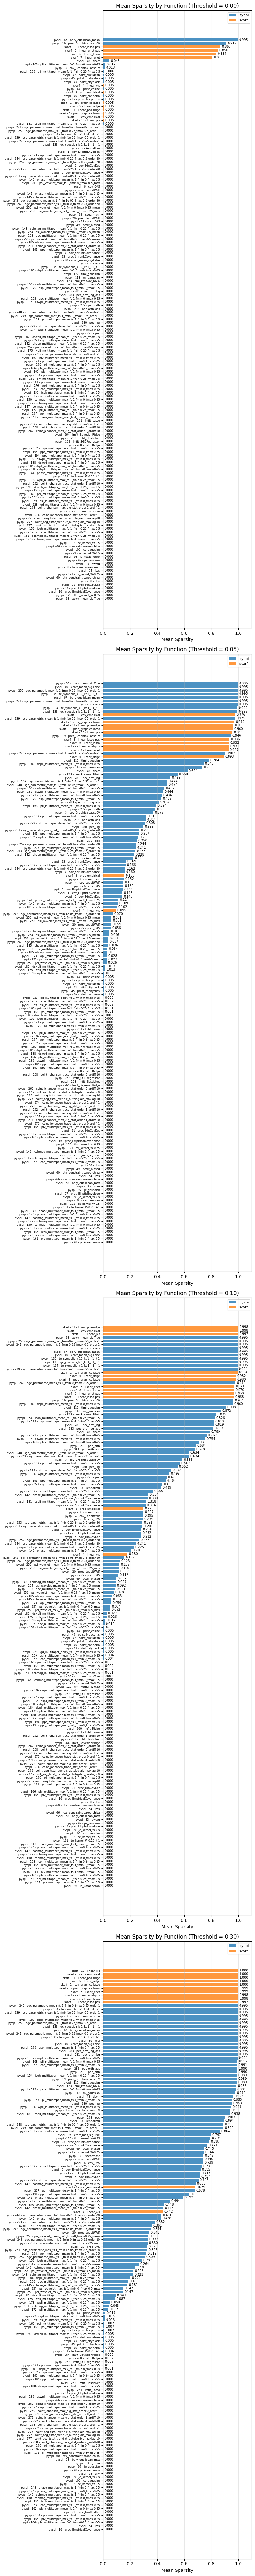

In [ ]:
thresholds_to_plot = THRESHOLDS

fig, axes = plt.subplots(len(thresholds_to_plot), 1, figsize=(8, 20 * len(thresholds_to_plot)))

colors = {'pyspi': '#1f77b4', 'skarf': '#ff7f0e'}

for idx, threshold in enumerate(thresholds_to_plot):
    ax = axes[idx] if len(thresholds_to_plot) > 1 else axes
    
    col_name = f'sparsity_t{threshold:.2f}_mean'
    
    plot_data = mean_sparsity.copy()
    plot_data['label'] = plot_data['method'] + ' - ' + plot_data['func_id'].astype(str) + ' - ' + plot_data['func']
    
    plot_data_sorted = plot_data.sort_values(col_name, ascending=True)
    
    y_positions = list(range(len(plot_data_sorted)))
    bar_colors = [colors[method] for method in plot_data_sorted['method']]
    
    bars = ax.barh(y_positions, plot_data_sorted[col_name], 
                   color=bar_colors, alpha=0.8)
    
    for i, (bar, val) in enumerate(zip(bars, plot_data_sorted[col_name])):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va='center', ha='left', fontsize=7)
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors['pyspi'], alpha=0.8, label='pyspi'),
                       Patch(facecolor=colors['skarf'], alpha=0.8, label='skarf')]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(plot_data_sorted['label'], fontsize=6)
    ax.set_xlabel('Mean Sparsity', fontsize=10)
    ax.set_title(f'Mean Sparsity by Function (Threshold = {threshold:.2f})', 
                 fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, 1.1)

plt.tight_layout()
plt.savefig("../output/mean_sparsity_by_function_all_thresholds.png", dpi=300)
plt.show()

In [20]:
for t in THRESHOLDS:
    col = f'sparsity_t{t:.2f}_mean'
    print(f"\nSummary Statistics by Method (at threshold {t:.2f}):")
    print("=" * 80)
    print(mean_sparsity.groupby('method')[col].describe())


Summary Statistics by Method (at threshold 0.00):
        count      mean       std    min    25%    50%      75%     max
method                                                                 
pyspi   149.0  0.013586  0.110212  0.000  0.000  0.000  0.00000  0.9950
skarf    12.0  0.283625  0.411764  0.005  0.005  0.005  0.81575  0.8683

Summary Statistics by Method (at threshold 0.05):
        count      mean       std     min      25%     50%     75%     max
method                                                                    
pyspi   149.0  0.174781  0.293314  0.0000  0.00000  0.0050  0.2406  0.9950
skarf    12.0  0.808217  0.319622  0.0951  0.91855  0.9339  0.9609  0.9759

Summary Statistics by Method (at threshold 0.10):
        count      mean       std     min       25%      50%       75%     max
method                                                                        
pyspi   149.0  0.237893  0.340245  0.0000  0.000000  0.00930  0.367800  0.9950
skarf    12.0  0.85868

## Save results

In [ ]:
output_path = "../output/mean_sparsity_by_function_all_thresholds.csv"
mean_sparsity.to_csv(output_path, index=False)
print(f"\nFull results saved to: {output_path}")

print(f"\n{'='*80}")
print(f"Overall Summary:")
print(f"{'='*80}")
for t in THRESHOLDS:
    col_name = f'sparsity_t{t:.2f}_mean'
    print(f"\nThreshold {t:.2f}:")
    print(f"  Min sparsity: {mean_sparsity[col_name].min():.4f}")
    print(f"  Max sparsity: {mean_sparsity[col_name].max():.4f}")
    print(f"  Mean sparsity: {mean_sparsity[col_name].mean():.4f}")
    print(f"  Median sparsity: {mean_sparsity[col_name].median():.4f}")


Full results saved to: ../output/mean_sparsity_by_function_all_thresholds.csv

Overall Summary:

Threshold 0.00:
  Min sparsity: 0.0000
  Max sparsity: 0.9950
  Mean sparsity: 0.0337
  Median sparsity: 0.0000

Threshold 0.05:
  Min sparsity: 0.0000
  Max sparsity: 0.9950
  Mean sparsity: 0.2220
  Median sparsity: 0.0265

Threshold 0.10:
  Min sparsity: 0.0000
  Max sparsity: 0.9984
  Mean sparsity: 0.2842
  Median sparsity: 0.0539

Threshold 0.30:
  Min sparsity: 0.0000
  Max sparsity: 1.0000
  Mean sparsity: 0.4258
  Median sparsity: 0.3258
